In [37]:
CSV_FILE      = "NTPC.csv"
MODEL_TYPE    = "LSTM"

INPUT_STEPS   = 10
OUTPUT_STEPS  = 5
OVERLAP       = 5
TRAIN_RATIO   = 0.8
BATCH_SIZE    = 32
EPOCHS        = 50
PATIENCE      = 10
LR            = 0.001
HIDDEN_SIZE   = 64
NUM_LAYERS    = 2
DROPOUT       = 0.2

FEATURES = [
    'Prev Close', 'Open', 'High', 'Low', 'Last',
    'Close', 'VWAP', 'Volume', 'Turnover',
    'Trades', 'Deliverable Volume'
]

NUM_FEATURES = 11

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Path to dataset files: /kaggle/input/nifty50-stock-market-data


In [12]:
import os

os.listdir(path)

['HDFCBANK.csv',
 'GRASIM.csv',
 'WIPRO.csv',
 'stock_metadata.csv',
 'BPCL.csv',
 'INFY.csv',
 'LT.csv',
 'RELIANCE.csv',
 'BRITANNIA.csv',
 'INFRATEL.csv',
 'HEROMOTOCO.csv',
 'HINDUNILVR.csv',
 'TATAMOTORS.csv',
 'MM.csv',
 'HDFC.csv',
 'JSWSTEEL.csv',
 'TITAN.csv',
 'HINDALCO.csv',
 'AXISBANK.csv',
 'HCLTECH.csv',
 'ADANIPORTS.csv',
 'GAIL.csv',
 'NIFTY50_all.csv',
 'BAJAJFINSV.csv',
 'BAJFINANCE.csv',
 'ICICIBANK.csv',
 'ZEEL.csv',
 'ASIANPAINT.csv',
 'IOC.csv',
 'TATASTEEL.csv',
 'COALINDIA.csv',
 'NESTLEIND.csv',
 'DRREDDY.csv',
 'ONGC.csv',
 'EICHERMOT.csv',
 'UPL.csv',
 'SUNPHARMA.csv',
 'ULTRACEMCO.csv',
 'CIPLA.csv',
 'SHREECEM.csv',
 'VEDL.csv',
 'TCS.csv',
 'NTPC.csv',
 'MARUTI.csv',
 'KOTAKBANK.csv',
 'ITC.csv',
 'BAJAJ-AUTO.csv',
 'SBIN.csv',
 'INDUSINDBK.csv',
 'BHARTIARTL.csv',
 'TECHM.csv',
 'POWERGRID.csv']

## Part 1 — Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [15]:
import os

# Load NTPC.csv
df = pd.read_csv(os.path.join(path, CSV_FILE))

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (4088, 15)

Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

First 5 rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2004-11-05,NTPC,EQ,62.00,88.00,88.00,70.00,75.55,75.55,73.12,232535736,1.700363e+15,NaN,115350904,0.4961
1,2004-11-08,NTPC,EQ,75.55,76.80,78.60,75.00,75.15,75.20,76.88,68865277,5.294024e+14,NaN,25571231,0.3713
2,2004-11-09,NTPC,EQ,75.20,75.10,76.10,74.55,75.25,75.30,75.28,37460886,2.820236e+14,NaN,13585363,0.3627
3,2004-11-10,NTPC,EQ,75.30,75.50,75.95,75.00,75.05,75.05,75.32,17413433,1.311585e+14,NaN,7039001,0.4042
4,2004-11-11,NTPC,EQ,75.05,75.35,75.40,74.30,74.60,74.45,74.74,15961426,1.193037e+14,NaN,7286922,0.4565


In [39]:
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Check Missing / NaN Values
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                1632
Deliverable Volume       0
%Deliverble              0
dtype: int64

Total missing values: 1632


In [40]:
print(" Check and Remove Duplicates")
dups = df.duplicated().sum()
print(f"Duplicate rows found: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

 Check and Remove Duplicates
Duplicate rows found: 0
No duplicates found.


In [41]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Invalid dates (NaT): {df['Date'].isnull().sum()}")

df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"\nAfter sorting by date: {df.shape}")

Date range: 2004-11-05 00:00:00 to 2021-04-30 00:00:00
Invalid dates (NaT): 0

After sorting by date: (4088, 15)


In [42]:
col_map = {}
for feat in FEATURES:
    if feat in df.columns:
        col_map[feat] = feat
    else:
        matches = [c for c in df.columns if feat.lower()[:5] in c.lower()]
        if matches:
            col_map[feat] = matches[0]
            print(f"  Mapped '{feat}' -> '{matches[0]}'")

deliverable_cols = [c for c in df.columns if 'deliv' in c.lower()]
print(f"\nDeliverable-related columns found: {deliverable_cols}")

available_features = [c for c in FEATURES if c in df.columns]
if 'Deliverable Volume' not in df.columns:
    pct_col = [c for c in df.columns if '%' in c or 'Pct' in c.lower() or 'pct' in c.lower()]
    if pct_col:
        available_features.append(pct_col[0])

print(f"\nFeatures selected ({len(available_features)}):", available_features)

df_feat = df[['Date'] + available_features].copy()
print(f"\nDataset shape: {df_feat.shape}")
df_feat.head()


Deliverable-related columns found: ['Deliverable Volume', '%Deliverble']

Features selected (11): ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

Dataset shape: (4088, 12)


,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,2004-11-05,62.00,88.00,88.00,70.00,75.55,75.55,73.12,232535736,1.700363e+15,NaN,115350904
1,2004-11-08,75.55,76.80,78.60,75.00,75.15,75.20,76.88,68865277,5.294024e+14,NaN,25571231
2,2004-11-09,75.20,75.10,76.10,74.55,75.25,75.30,75.28,37460886,2.820236e+14,NaN,13585363
3,2004-11-10,75.30,75.50,75.95,75.00,75.05,75.05,75.32,17413433,1.311585e+14,NaN,7039001
4,2004-11-11,75.05,75.35,75.40,74.30,74.60,74.45,74.74,15961426,1.193037e+14,NaN,7286922


In [43]:
print("Missing before interpolation:")
print(df_feat.isnull().sum())

df_feat[available_features] = df_feat[available_features].interpolate(
    method='linear', limit_direction='both'
)
df_feat[available_features] = df_feat[available_features].ffill().bfill()

print("\nMissing after interpolation:")
print(df_feat.isnull().sum())
print(f"\nFinal shape: {df_feat.shape}")

Missing before interpolation:
Date                     0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                1632
Deliverable Volume       0
dtype: int64

Missing after interpolation:
Date                  0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

Final shape: (4088, 12)


In [44]:
print(df_feat.dtypes)

for col in available_features:
    df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')

df_feat[available_features] = df_feat[available_features].ffill().bfill()
print("\nAll feature columns converted to float.")
print(df_feat.dtypes)

Date                  datetime64[ns]
Prev Close                   float64
Open                         float64
High                         float64
Low                          float64
Last                         float64
Close                        float64
VWAP                         float64
Volume                         int64
Turnover                     float64
Trades                       float64
Deliverable Volume             int64
dtype: object

All feature columns converted to float.
Date                  datetime64[ns]
Prev Close                   float64
Open                         float64
High                         float64
Low                          float64
Last                         float64
Close                        float64
VWAP                         float64
Volume                         int64
Turnover                     float64
Trades                       float64
Deliverable Volume             int64
dtype: object


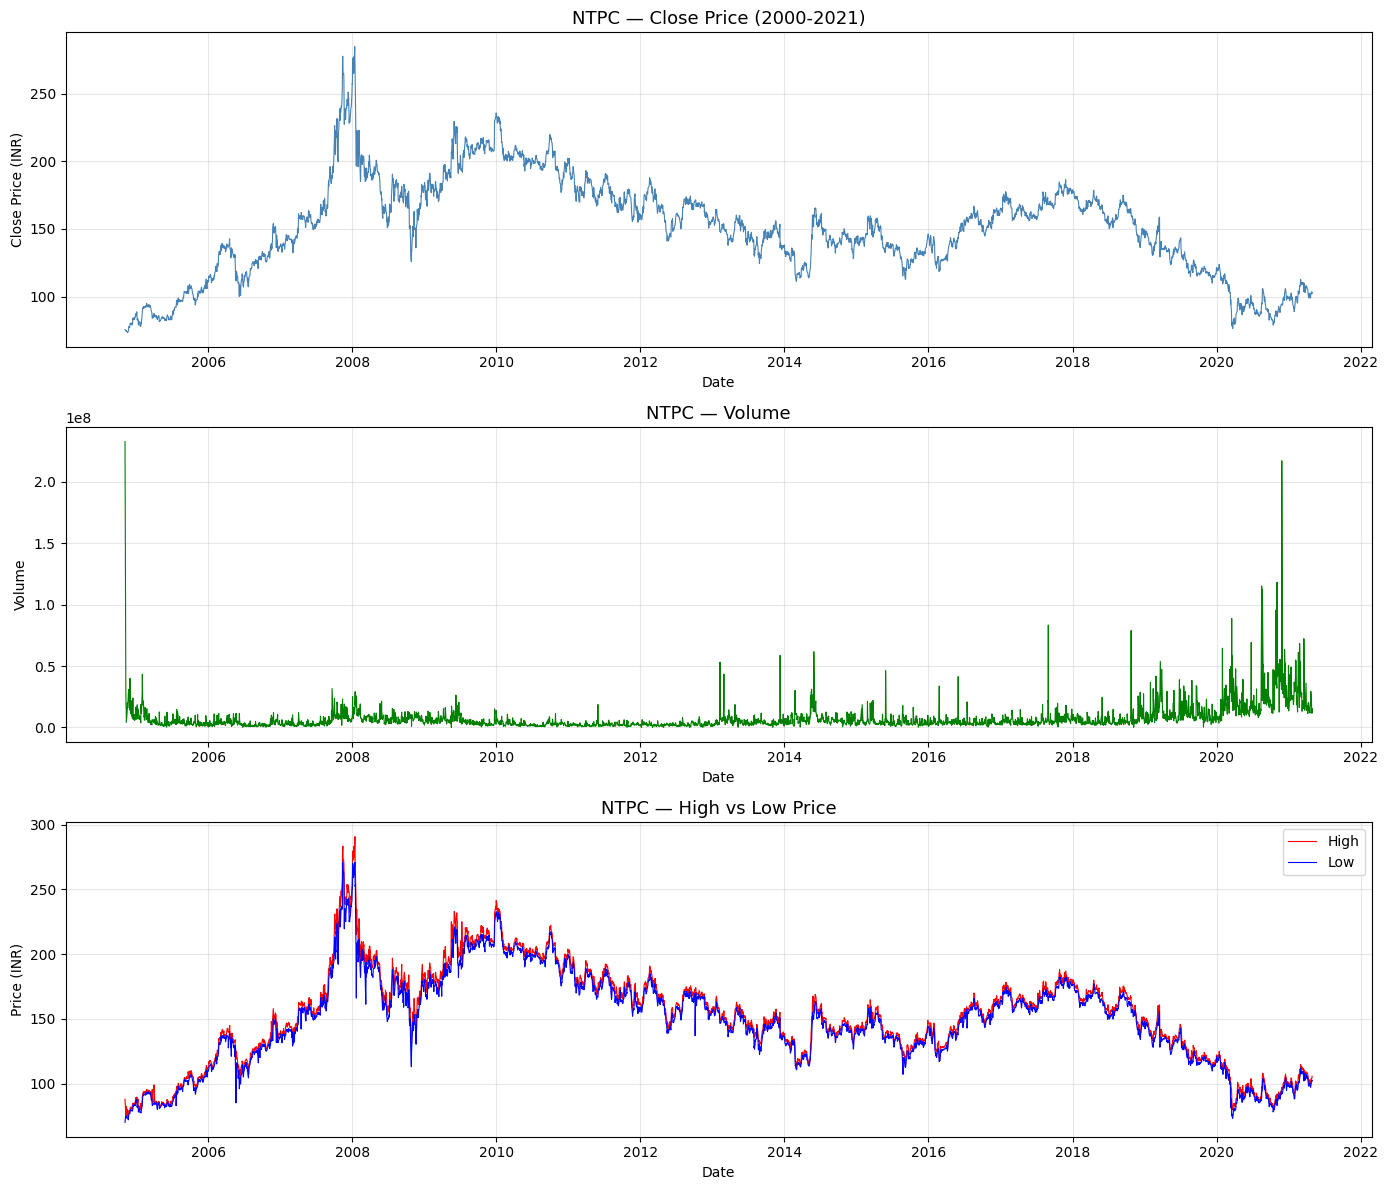

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df_feat['Date'], df_feat['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('NTPC — Close Price (2000-2021)', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Close Price (INR)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_feat['Date'], df_feat['Volume'], color='green', linewidth=0.8)
axes[1].set_title('NTPC — Volume', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_feat['Date'], df_feat['High'], color='red', linewidth=0.8, label='High')
axes[2].plot(df_feat['Date'], df_feat['Low'], color='blue', linewidth=0.8, label='Low')
axes[2].set_title('NTPC — High vs Low Price', fontsize=13)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (INR)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
dates     = df_feat['Date'].values
data_vals = df_feat[available_features].values.astype(np.float32)

NUM_FEATURES = data_vals.shape[1]
print(f"Actual number of features used: {NUM_FEATURES}")


split_idx  = int(len(data_vals) * TRAIN_RATIO)
train_data = data_vals[:split_idx]
test_data  = data_vals[split_idx:]
train_dates = dates[:split_idx]
test_dates  = dates[split_idx:]

print(f"Train: {train_data.shape}  ({train_dates[0]} to {train_dates[-1]})")
print(f"Test:  {test_data.shape}   ({test_dates[0]} to {test_dates[-1]})")

Actual number of features used: 11
Train: (3270, 11)  (2004-11-05T00:00:00.000000000 to 2018-01-05T00:00:00.000000000)
Test:  (818, 11)   (2018-01-08T00:00:00.000000000 to 2021-04-30T00:00:00.000000000)


In [47]:
train_norm = normalize(train_data, norm='l2', axis=0)
test_norm  = normalize(test_data,  norm='l2', axis=0)


# scaler = StandardScaler()
# train_norm = scaler.fit_transform(train_data)
# test_norm  = scaler.transform(test_data)

In [48]:
def create_sequences(data, input_steps, output_steps, overlap):

    X, y = [], []
    stride = input_steps - overlap
    if stride <= 0:
        stride = 1

    for i in range(0, len(data) - input_steps - output_steps + 1, stride):
        X.append(data[i : i + input_steps])
        y.append(data[i + input_steps : i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_test,  y_test  = create_sequences(test_norm,  INPUT_STEPS, OUTPUT_STEPS, OVERLAP)

print(f"Input steps:  {INPUT_STEPS} days | Output steps: {OUTPUT_STEPS} days | Overlap: {OVERLAP} days")
print(f"X_train: {X_train.shape}  → (samples, input_steps, features)")
print(f"y_train: {y_train.shape}  → (samples, output_steps, features)")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

Input steps:  10 days | Output steps: 5 days | Overlap: 5 days
X_train: (652, 10, 11)  → (samples, input_steps, features)
y_train: (652, 5, 11)  → (samples, output_steps, features)
X_test:  (161, 10, 11)
y_test:  (161, 5, 11)


In [26]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset  = StockDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Verify shape
for X_b, y_b in train_loader:
    print(f"Batch X shape: {X_b.shape}  → (batch, input_steps, features)")
    print(f"Batch y shape: {y_b.shape}  → (batch, output_steps, features)")
    break

Train batches: 21
Test  batches: 6
Batch X shape: torch.Size([32, 10, 11])  → (batch, input_steps, features)
Batch y shape: torch.Size([32, 5, 11])  → (batch, output_steps, features)


In [27]:
class StockForecaster(nn.Module):
    def __init__(self, model_type, input_size, hidden_size,
                 num_layers, output_steps, num_features, dropout):
        super(StockForecaster, self).__init__()

        self.model_type  = model_type
        self.output_steps = output_steps
        self.num_features = num_features

        if model_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size  = input_size,
                hidden_size = hidden_size,
                num_layers  = num_layers,
                batch_first = True,
                dropout     = dropout if num_layers > 1 else 0
            )
        elif model_type == "GRU":
            self.rnn = nn.GRU(
                input_size  = input_size,
                hidden_size = hidden_size,
                num_layers  = num_layers,
                batch_first = True,
                dropout     = dropout if num_layers > 1 else 0
            )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_steps * num_features)

    def forward(self, x):
        if self.model_type == "LSTM":
            out, (hn, cn) = self.rnn(x)
        else:
            out, hn = self.rnn(x)

        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        out = out.view(-1, self.output_steps, self.num_features)
        return out

model = StockForecaster(
    model_type   = MODEL_TYPE,
    input_size   = NUM_FEATURES,
    hidden_size  = HIDDEN_SIZE,
    num_layers   = NUM_LAYERS,
    output_steps = OUTPUT_STEPS,
    num_features = NUM_FEATURES,
    dropout      = DROPOUT
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

StockForecaster(
  (rnn): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=55, bias=True)
)

Total trainable parameters: 56,567


In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        preds = model(X_b)
        loss  = criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds     = model(X_b)
            loss      = criterion(preds, y_b)
            total_loss += loss.item() * X_b.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_b.cpu().numpy())
    avg_loss    = total_loss / len(loader.dataset)
    all_preds   = np.concatenate(all_preds,   axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return avg_loss, all_preds, all_targets

#  Training Loop with Early Stopping
train_losses      = []
test_losses       = []
best_test_loss    = float('inf')
epochs_no_improve = 0

print(f"Training {MODEL_TYPE} model for up to {EPOCHS} epochs...")
print("-" * 70)

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, preds, targets = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model_ntpc.pt')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_ntpc.pt'))
print(f"\nBest model loaded! Best Test Loss: {best_test_loss:.6f}")

Training LSTM model for up to 50 epochs...
----------------------------------------------------------------------
Epoch [  1/50] | Train Loss: 0.001663 | Test Loss: 0.000566
Epoch [  5/50] | Train Loss: 0.000148 | Test Loss: 0.000505
Epoch [ 10/50] | Train Loss: 0.000093 | Test Loss: 0.000478
Epoch [ 15/50] | Train Loss: 0.000075 | Test Loss: 0.000481
Epoch [ 20/50] | Train Loss: 0.000067 | Test Loss: 0.000473
Epoch [ 25/50] | Train Loss: 0.000063 | Test Loss: 0.000457
Epoch [ 30/50] | Train Loss: 0.000059 | Test Loss: 0.000452
Epoch [ 35/50] | Train Loss: 0.000055 | Test Loss: 0.000429
Epoch [ 40/50] | Train Loss: 0.000052 | Test Loss: 0.000407
Epoch [ 45/50] | Train Loss: 0.000049 | Test Loss: 0.000342
Epoch [ 50/50] | Train Loss: 0.000044 | Test Loss: 0.000278

Best model loaded! Best Test Loss: 0.000278


## Part 11 — Loss Curves

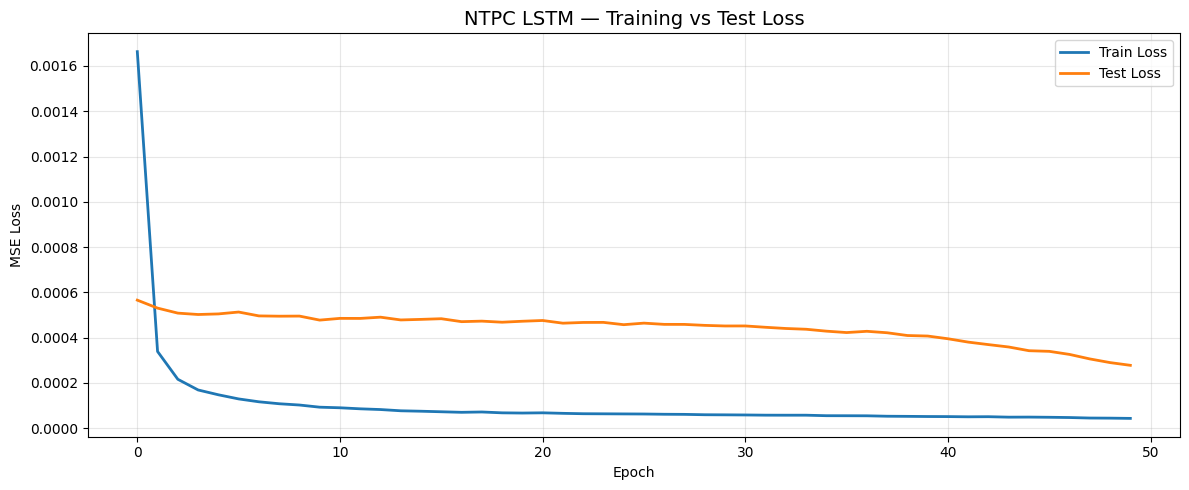

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  linewidth=2)
plt.title(f'NTPC {MODEL_TYPE} — Training vs Test Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 12 — Performance Metrics (MSE, RMSE, MAE)

In [49]:
_, final_preds, final_targets = evaluate(model, test_loader, criterion)

preds_flat   = final_preds.reshape(-1)
targets_flat = final_targets.reshape(-1)

mse  = mean_squared_error(targets_flat, preds_flat)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_flat, preds_flat)

print("=" * 50)
print(f"  MODEL    : {MODEL_TYPE}")
print(f"  DATASET  : NTPC.csv (Roll No: 25MCA035)")
print(f"  INPUT    : {INPUT_STEPS} days → OUTPUT: {OUTPUT_STEPS} days")
print(f"  FEATURES : {NUM_FEATURES}")
print("=" * 50)
print(f"  MSE  (Mean Squared Error)       : {mse:.6f}")
print(f"  RMSE (Root Mean Squared Error)  : {rmse:.6f}")
print(f"  MAE  (Mean Absolute Error)      : {mae:.6f}")
print("=" * 50)

print("\nPer-Feature Metrics:")
print(f"{'Feature':<25} {'MSE':>12} {'RMSE':>12} {'MAE':>12}")
print("-" * 62)
for i, feat in enumerate(available_features):
    p = final_preds[:, :, i].reshape(-1)
    t = final_targets[:, :, i].reshape(-1)
    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)
    print(f"{feat:<25} {f_mse:>12.6f} {f_rmse:>12.6f} {f_mae:>12.6f}")

  MODEL    : LSTM
  DATASET  : NTPC.csv (Roll No: 25MCA035)
  INPUT    : 10 days → OUTPUT: 5 days
  FEATURES : 11
  MSE  (Mean Squared Error)       : 0.000278
  RMSE (Root Mean Squared Error)  : 0.016672
  MAE  (Mean Absolute Error)      : 0.010604

Per-Feature Metrics:
Feature                            MSE         RMSE          MAE
--------------------------------------------------------------
Prev Close                    0.000080     0.008965     0.007502
Open                          0.000079     0.008887     0.007632
High                          0.000202     0.014207     0.012331
Low                           0.000094     0.009700     0.007969
Last                          0.000087     0.009333     0.008214
Close                         0.000116     0.010752     0.009079
VWAP                          0.000102     0.010114     0.008511
Volume                        0.000605     0.024589     0.013821
Turnover                      0.000551     0.023466     0.014951
Trades          

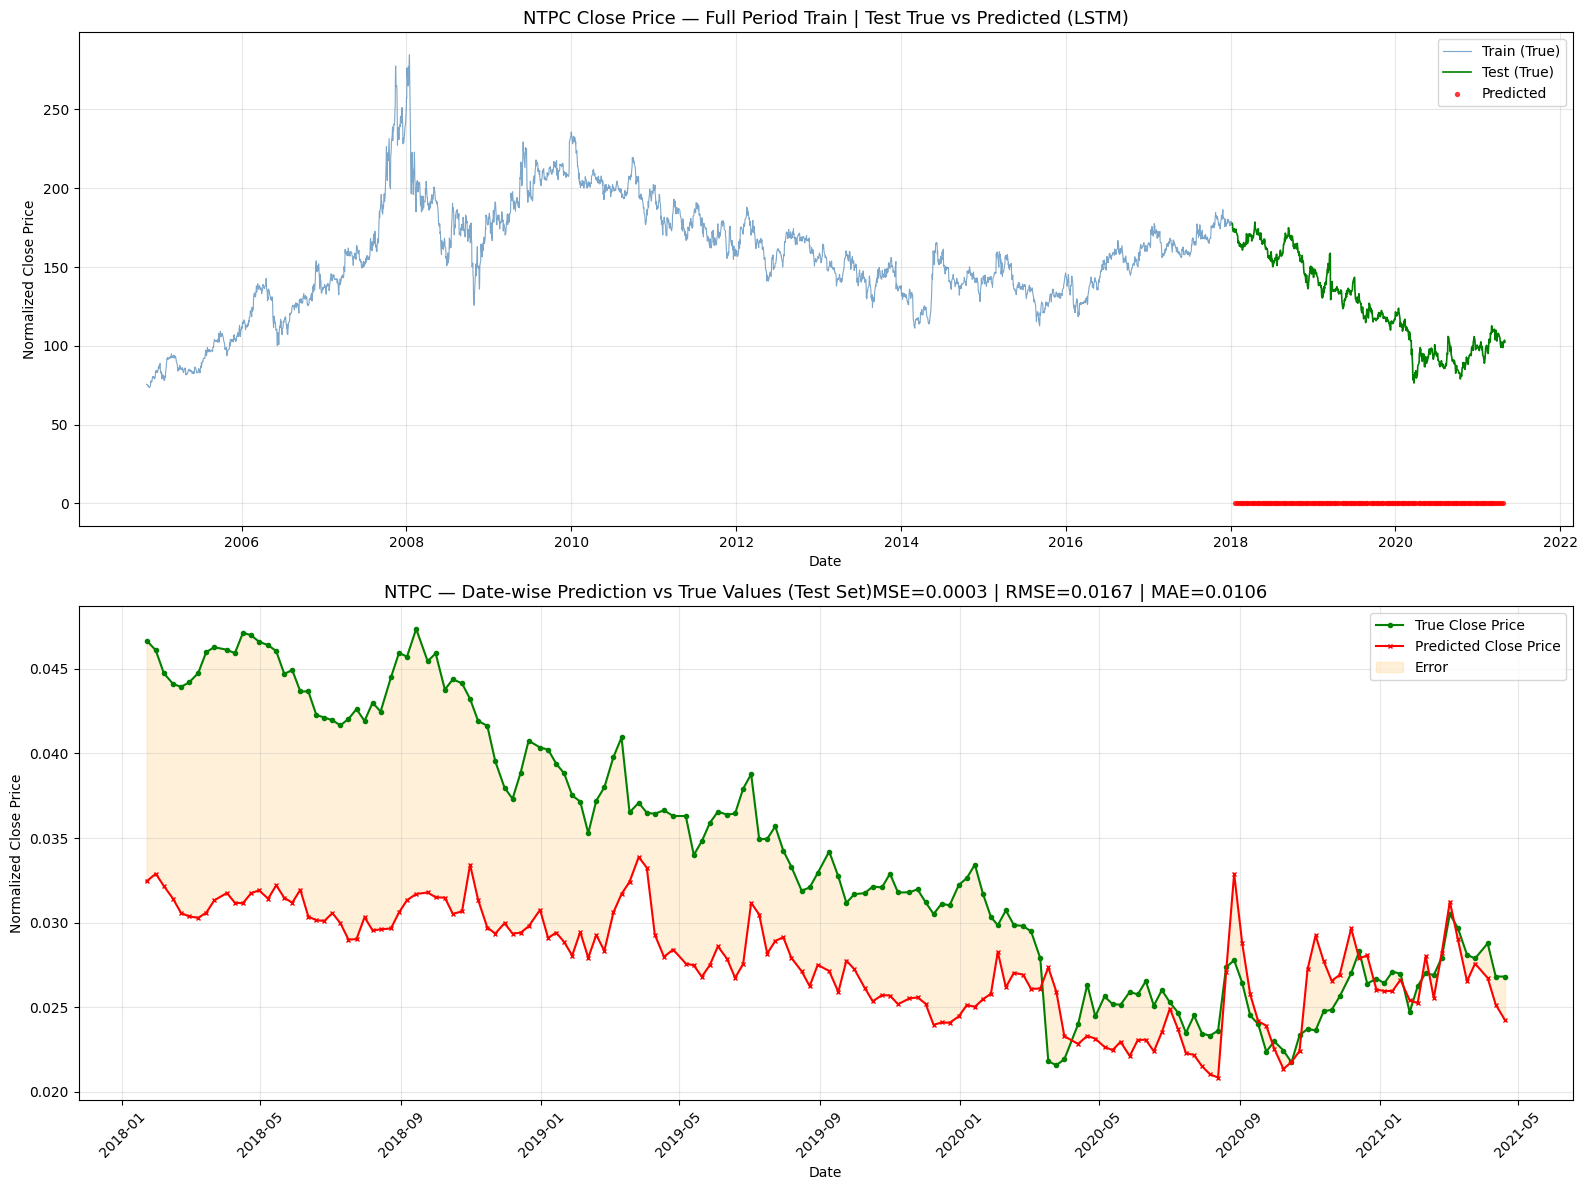

Plot saved as 'NTPC_predictions.png'


In [32]:
stride = INPUT_STEPS - OVERLAP if (INPUT_STEPS - OVERLAP) > 0 else 1
pred_start_indices = list(range(
    INPUT_STEPS,
    len(test_norm) - OUTPUT_STEPS + 1,
    stride
))[:len(final_preds)]

pred_dates = []
for idx in pred_start_indices:
    actual_idx = split_idx + idx
    if actual_idx < len(dates):
        pred_dates.append(pd.Timestamp(dates[actual_idx]))
    else:
        pred_dates.append(pd.Timestamp(dates[-1]))

pred_dates = pred_dates[:len(final_preds)]

close_idx = available_features.index('Close') if 'Close' in available_features else 5

pred_close = final_preds[:, 0, close_idx]
true_close = final_targets[:, 0, close_idx]

test_close_all  = test_data[:, close_idx]
test_dates_all  = pd.to_datetime(test_dates)
pred_dates_plot = pd.to_datetime(pred_dates[:len(pred_close)])

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

train_close = train_data[:, close_idx]
train_dates_plot = pd.to_datetime(train_dates)

axes[0].plot(train_dates_plot, train_close,
             color='steelblue', linewidth=0.8, label='Train (True)', alpha=0.7)
axes[0].plot(test_dates_all, test_close_all,
             color='green', linewidth=1.2, label='Test (True)')
axes[0].scatter(pred_dates_plot, pred_close,
                color='red', s=8, label='Predicted', zorder=5, alpha=0.7)
axes[0].set_title(f'NTPC Close Price — Full Period Train | Test True vs Predicted ({MODEL_TYPE})',fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Close Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(pred_dates_plot, true_close,
             color='green', linewidth=1.5, marker='o', markersize=3,
             label='True Close Price')
axes[1].plot(pred_dates_plot, pred_close,
             color='red', linewidth=1.5, marker='x', markersize=3,
             label='Predicted Close Price')
axes[1].fill_between(pred_dates_plot,
                     true_close, pred_close,
                     alpha=0.15, color='orange', label='Error')
axes[1].set_title(f'NTPC — Date-wise Prediction vs True Values (Test Set)'f'MSE={mse:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}',fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Normalized Close Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('NTPC_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'NTPC_predictions.png'")

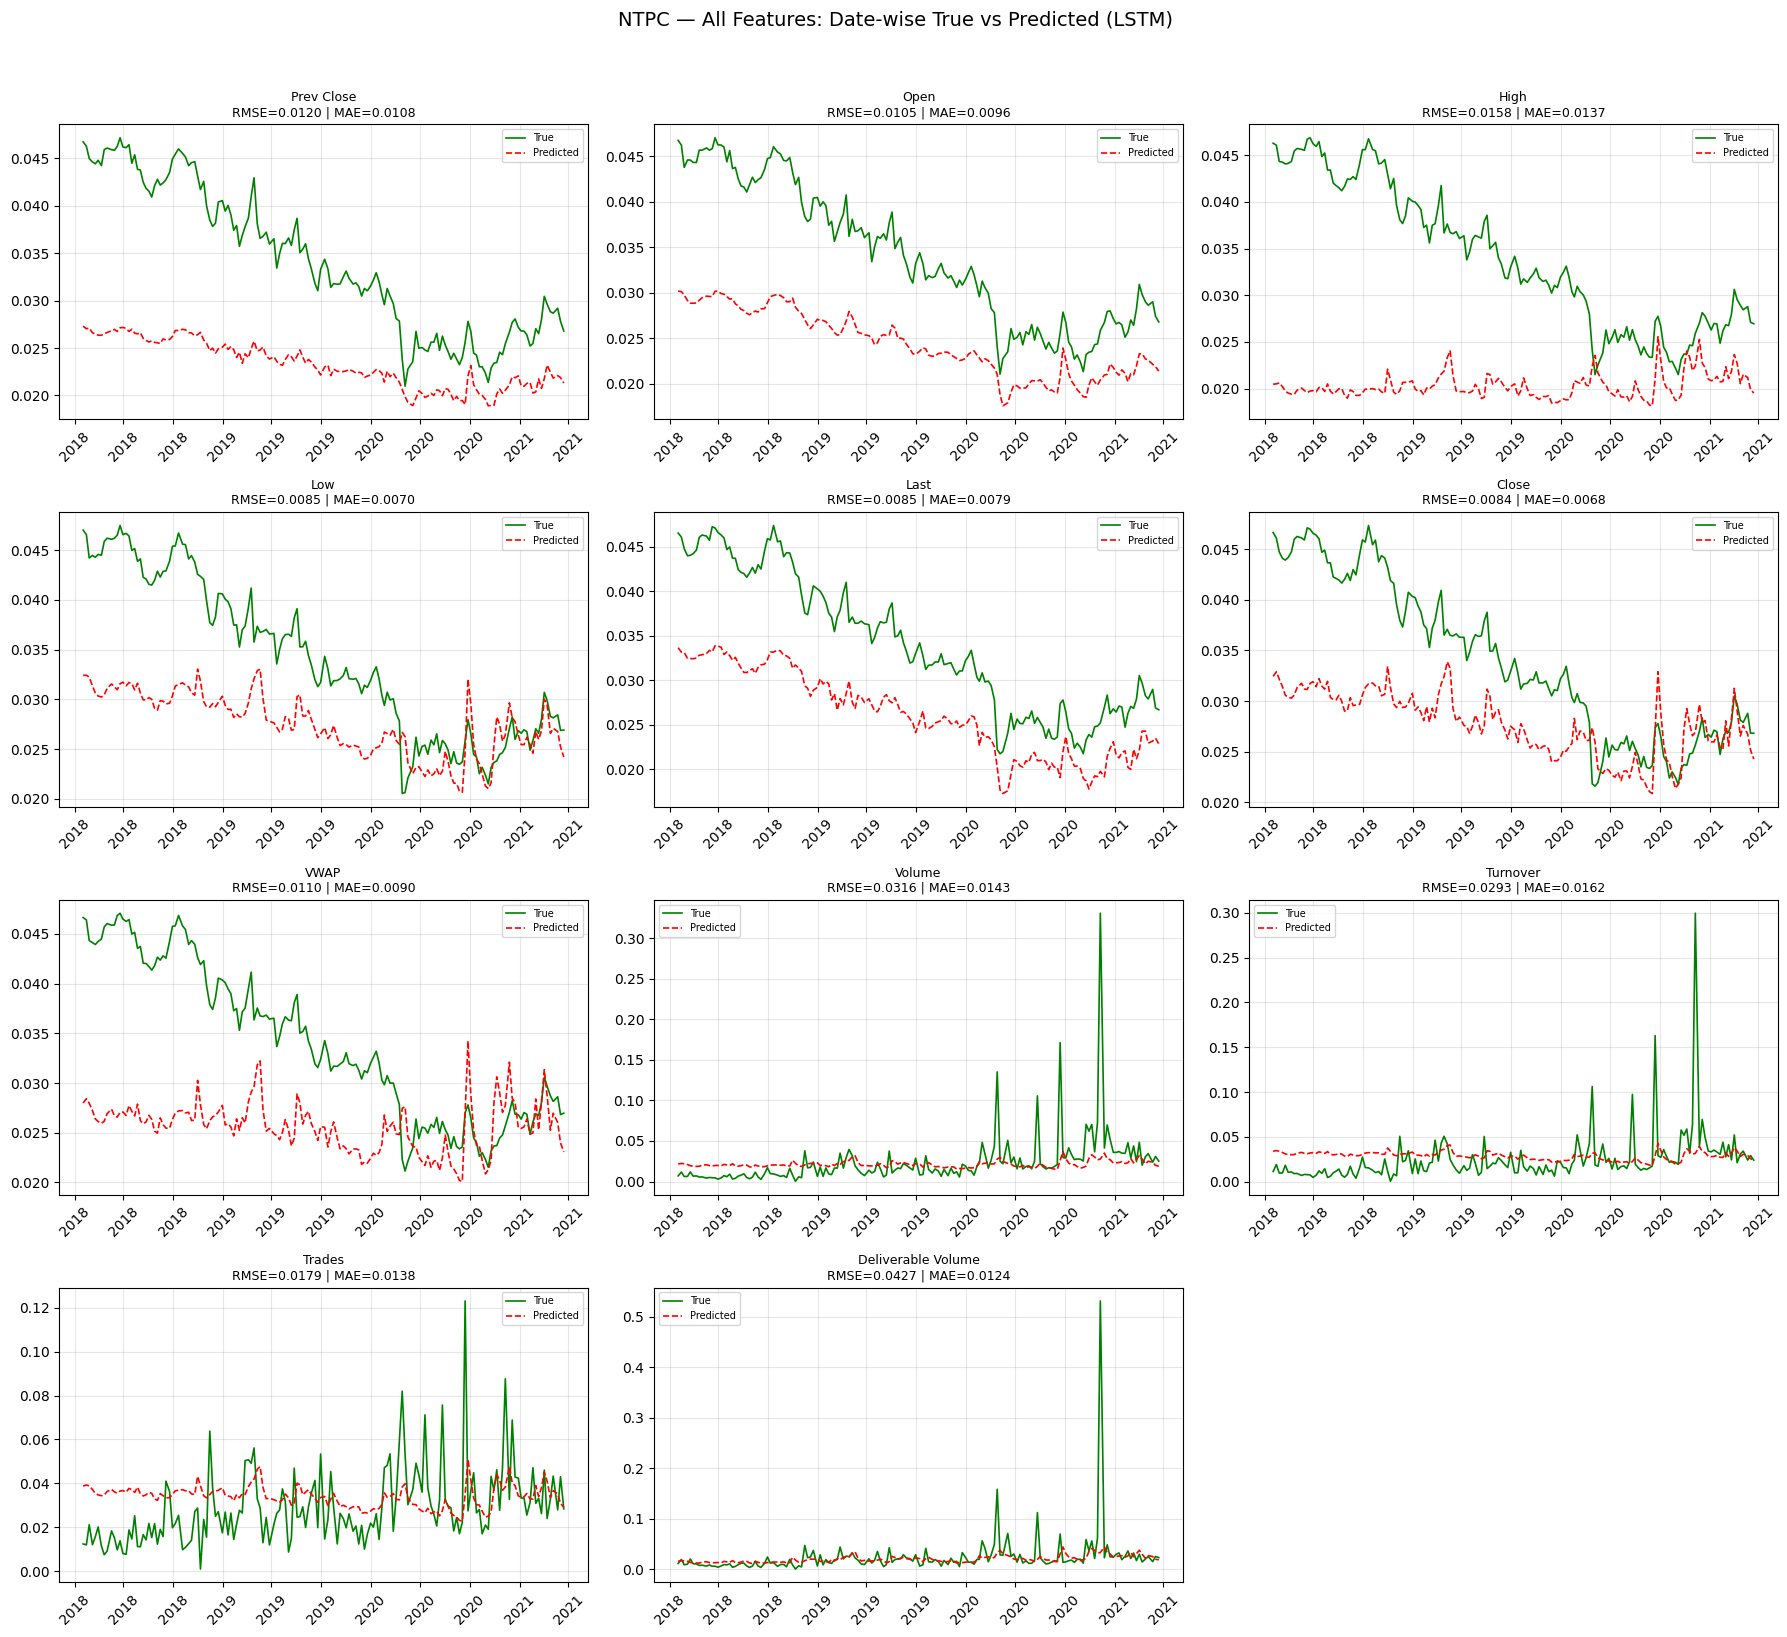

All-features plot saved!


In [33]:
n_feats = NUM_FEATURES
cols = 3
rows = (n_feats + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(available_features):
    p = final_preds[:, 0, i]
    t = final_targets[:, 0, i]

    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)

    ax = axes[i]
    ax.plot(pred_dates_plot[:len(t)], t,
            color='green', linewidth=1.2, label='True')
    ax.plot(pred_dates_plot[:len(p)], p,
            color='red',   linewidth=1.2, label='Predicted', linestyle='--')
    ax.set_title(f'{feat}\nRMSE={f_rmse:.4f} | MAE={f_mae:.4f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'NTPC — All Features: Date-wise True vs Predicted ({MODEL_TYPE})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('NTPC_all_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("All-features plot saved!")

In [50]:
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE'],
    'Value':  [f"{mse:.6f}", f"{rmse:.6f}", f"{mae:.6f}"],
}
results_df = pd.DataFrame(metrics_data)
print(results_df.to_string(index=False))

Metric    Value
   MSE 0.000278
  RMSE 0.016672
   MAE 0.010604
